In [2]:
print("Hello Tanya")

Hello Tanya


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
emp= pd.read_csv("occupazione.csv")
unemp=pd.read_csv("disoccupazione.csv")
emp.head()
unemp.head()

,iso_code,country,sex,age,year,obs_value
0,AFG,Afghanistan,Total,15+,2025,13.351
1,AFG,Afghanistan,Total,15-24,2025,16.785
2,AFG,Afghanistan,Total,25+,2025,11.340
3,AFG,Afghanistan,Male,15+,2025,12.503
4,AFG,Afghanistan,Male,15-24,2025,15.814


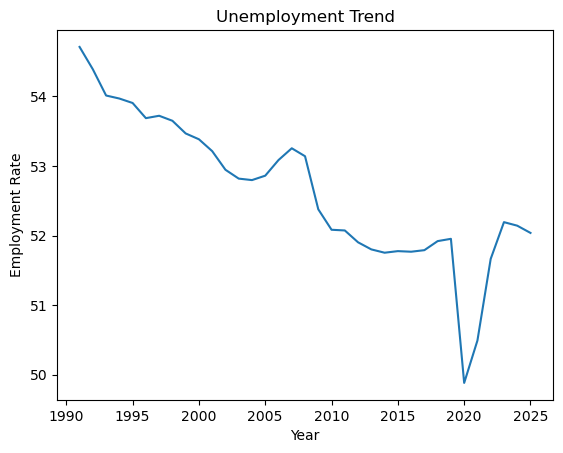

In [9]:
trend=emp.groupby('year')['obs_value'].mean()
import matplotlib.pyplot as plt
plt.title("Unemployment Trend")
plt.plot(trend.index,trend.values)
plt.xlabel("Year")
plt.ylabel("Employment Rate")
plt.show()

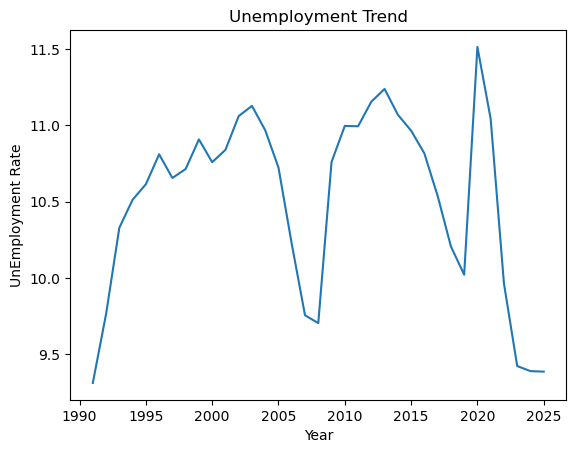

In [10]:
trend2=unemp.groupby('year')['obs_value'].mean()

plt.plot(trend2.index,trend2.values)
plt.title("Unemployment Trend")
plt.xlabel("Year")
plt.ylabel("UnEmployment Rate")
plt.show()

In [11]:
merged=pd.merge(emp,unemp,on=['iso_code','country','sex','age','year'])

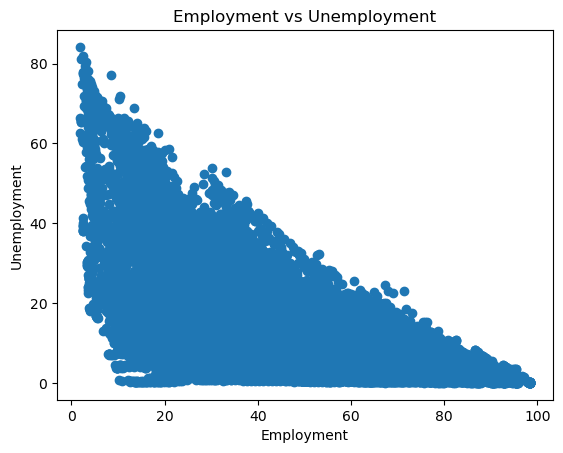

In [26]:
plt.scatter(merged['obs_value_x'],merged['obs_value_y'])
plt.xlabel("Employment")
plt.ylabel("Unemployment")
plt.title("Employment vs Unemployment")

plt.savefig("graph1.png")
plt.show()

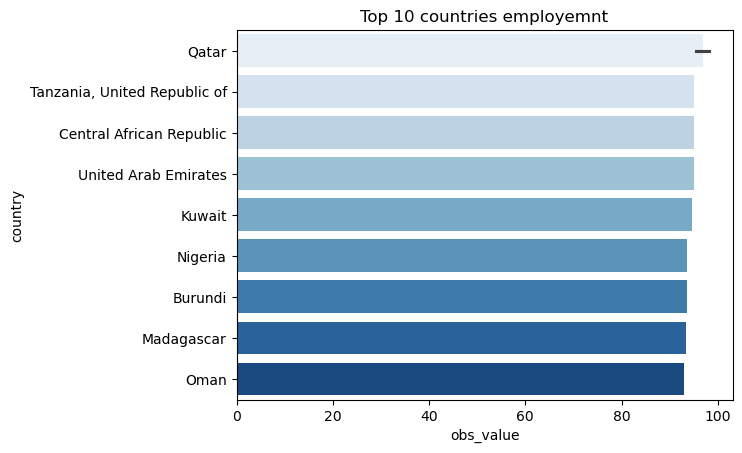

In [33]:
top=emp[emp['year']==2025].sort_values(by='obs_value',ascending=False).head(10)
sns.barplot(data=top, x='obs_value', y='country',hue='country',palette='Blues',legend=False)
plt.title("Top 10 countries employemnt")
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.savefig("graph3.png",transparent=True)
plt.show()

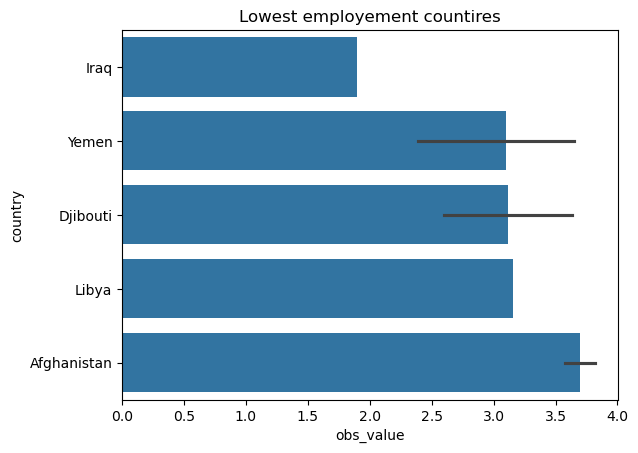

In [15]:
bottom=emp[emp['year']==2025].sort_values(by='obs_value').head(10)
sns.barplot(data=bottom,x='obs_value',y='country')
plt.title("Lowest employement countires")
plt.show()

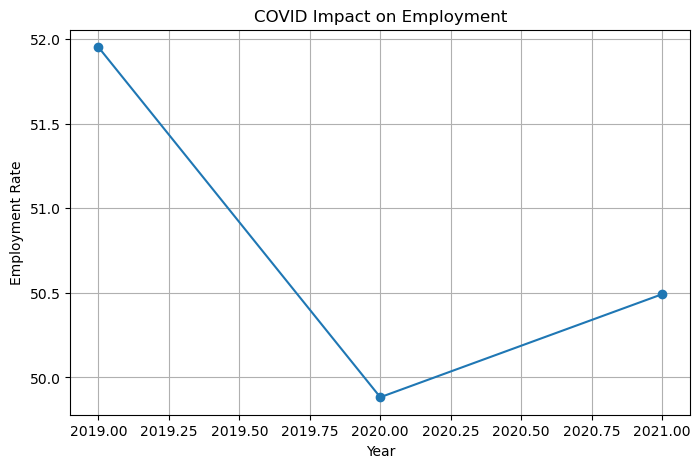

In [34]:


covid = emp[emp['year'].isin([2019, 2020, 2021])]
trend = covid.groupby('year')['obs_value'].mean()

plt.figure(figsize=(8,5))
plt.plot(trend.index, trend.values, marker='o')
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.savefig("graph4.png",transparent=True)
plt.title("COVID Impact on Employment")
plt.xlabel("Year")
plt.ylabel("Employment Rate")

plt.grid(True)  # grid add for clarity

plt.show()

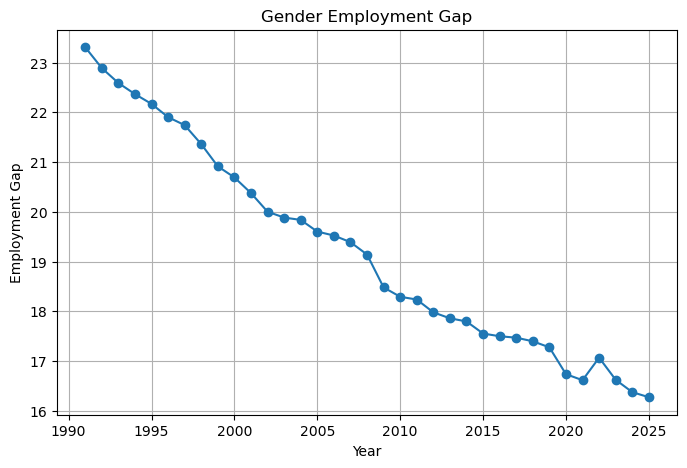

In [35]:
import matplotlib.pyplot as plt

male = emp[emp['sex'] == 'Male'].groupby('year')['obs_value'].mean()
female = emp[emp['sex'] == 'Female'].groupby('year')['obs_value'].mean()

gap = male - female

plt.figure(figsize=(8,5))
plt.plot(gap.index, gap.values, marker='o')

plt.title("Gender Employment Gap")
plt.xlabel("Year")                # X-axis label
plt.ylabel("Employment Gap")      # Y-axis label
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)
plt.savefig("graph4.png",transparent=True)
plt.grid(True)

plt.show()

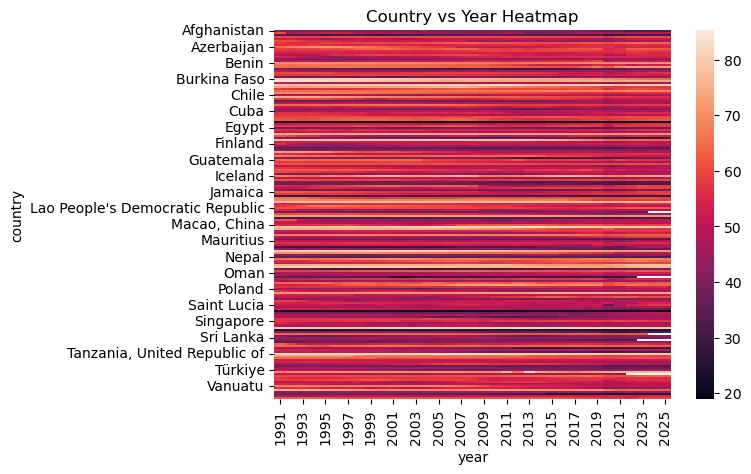

In [20]:
pivot = emp.pivot_table(values='obs_value', index='country', columns='year')

sns.heatmap(pivot)
plt.title("Country vs Year Heatmap")
plt.show()

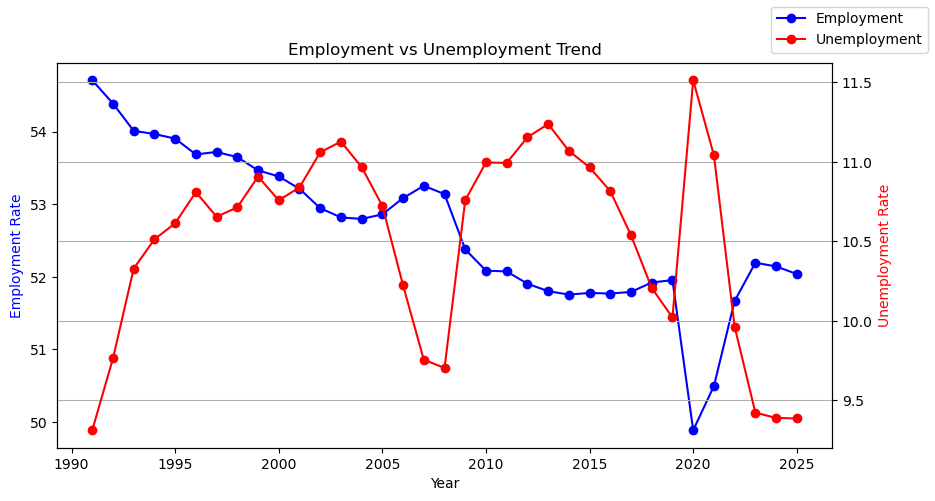

In [25]:
emp_trend = emp.groupby('year')['obs_value'].mean()
unemp_trend = unemp.groupby('year')['obs_value'].mean()

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,5))

# Employment (Blue)
ax1.plot(emp_trend.index, emp_trend.values, marker='o', color='blue', label='Employment')
ax1.set_xlabel("Year")
ax1.set_ylabel("Employment Rate", color='blue')

# Unemployment (Red)
ax2 = ax1.twinx()
ax2.plot(unemp_trend.index, unemp_trend.values, marker='o', color='red', label='Unemployment')
ax2.set_ylabel("Unemployment Rate", color='red')

plt.title("Employment vs Unemployment Trend")

fig.legend(loc="upper right")  # legend show karega
plt.grid(True)

plt.savefig("graph.png")
plt.show()

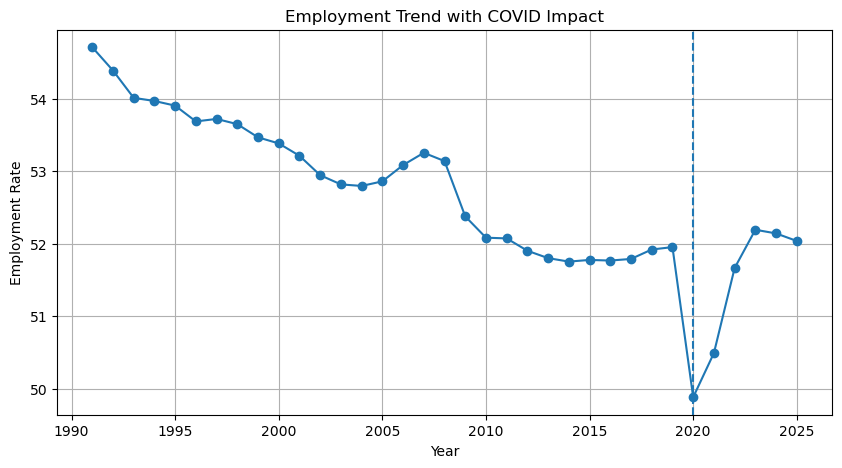

In [23]:
plt.figure(figsize=(10,5))

plt.plot(emp_trend.index, emp_trend.values, marker='o')

plt.axvline(x=2020, linestyle='--')  # COVID highlight

plt.title("Employment Trend with COVID Impact")
plt.xlabel("Year")
plt.ylabel("Employment Rate")

plt.grid(True)
plt.show()